# Notebook 03 — Analysis and Visualization

## What does this notebook do?

Analyzes the 90 experiment results from Notebook 02 and produces paper-ready figures:

- Figure 1: Accuracy Drop vs Calibration Size
- Figure 2: ECE vs Calibration Size
- Figure 3: Model Size & Latency Comparison
- Figure 4: Saturation Analysis
- Statistical tests (Wilcoxon, Spearman)
- LaTeX tables

## Models
This version analyzes **3 models**:
- ResNet-18
- ResNet-50
- MobileNetV2

**Note:** EfficientNet-B0 was excluded because its architecture (SiLU activation + SqueezeExcitation multiplication) is not supported by PyTorch's eager-mode static PTQ. This limitation is mentioned as a footnote in the paper.

**Prerequisite:** Notebook 02 must be completed (90 runs).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os, sys
shutil.copytree('/content/drive/MyDrive/imagenet_v2',
                '/content/mlcalib_v2', dirs_exist_ok=True)
os.chdir('/content/mlcalib_v2')
sys.path.insert(0, '/content/mlcalib_v2')

!pip install scikit-learn matplotlib seaborn scipy pandas -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

from config import FIGURES_DIR, RESULTS_AGG_DIR, CALIB_SIZES
os.makedirs(FIGURES_DIR, exist_ok=True)

# 3-model version — efficientnet_b0 excluded
MODELS = ['resnet18', 'resnet50', 'mobilenet_v2']

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
MODEL_COLORS = {
    'resnet18':     '#1565C0',
    'resnet50':     '#2196F3',
    'mobilenet_v2': '#FF5722',
}
MODEL_LABELS = {
    'resnet18':     'ResNet-18',
    'resnet50':     'ResNet-50',
    'mobilenet_v2': 'MobileNetV2',
}

summary = pd.read_csv(os.path.join(RESULTS_AGG_DIR, 'summary.csv'))
all_df  = pd.read_csv(os.path.join(RESULTS_AGG_DIR, 'all_results.csv'))

summary = summary[summary['model'].isin(MODELS)]
all_df  = all_df[all_df['model'].isin(MODELS)]

print(f'Total runs: {len(all_df)} (expected: 90)')
print(f'Models: {sorted(all_df["model"].unique())}')
display(summary.head(8))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total runs: 90 (expected: 90)
Models: ['mobilenet_v2', 'resnet18', 'resnet50']


,model,calib_size,fp32_accuracy_mean,fp32_accuracy_std,int8_accuracy_mean,int8_accuracy_std,accuracy_drop_mean,accuracy_drop_std,ece_mean,ece_std,model_size_mb_mean,model_size_mb_std,latency_ms_mean,latency_ms_std
0,mobilenet_v2,10,71.00,0.0,50.708,10.4981,20.292,10.4981,0.1280,0.0841,4.049,0.0,438.6038,27.2255
1,mobilenet_v2,50,71.00,0.0,35.212,3.3909,35.788,3.3909,0.2093,0.0436,4.049,0.0,456.1228,3.9530
2,mobilenet_v2,100,71.00,0.0,33.992,1.9174,37.008,1.9174,0.2225,0.0279,4.049,0.0,482.7794,20.3306
3,mobilenet_v2,500,71.00,0.0,35.884,2.6761,35.116,2.6761,0.1976,0.0397,4.049,0.0,490.6298,7.7714
4,mobilenet_v2,1000,71.00,0.0,34.568,2.5647,36.432,2.5647,0.2204,0.0251,4.049,0.0,485.8648,7.4543
5,mobilenet_v2,5000,71.00,0.0,34.868,1.3561,36.132,1.3561,0.2044,0.0274,4.049,0.0,509.3682,14.8676
6,resnet18,10,69.06,0.0,68.932,0.1180,0.128,0.1180,0.0332,0.0020,11.292,0.0,366.2220,7.4581
7,resnet18,50,69.06,0.0,68.784,0.1099,0.276,0.1099,0.0343,0.0022,11.292,0.0,362.9894,3.7958


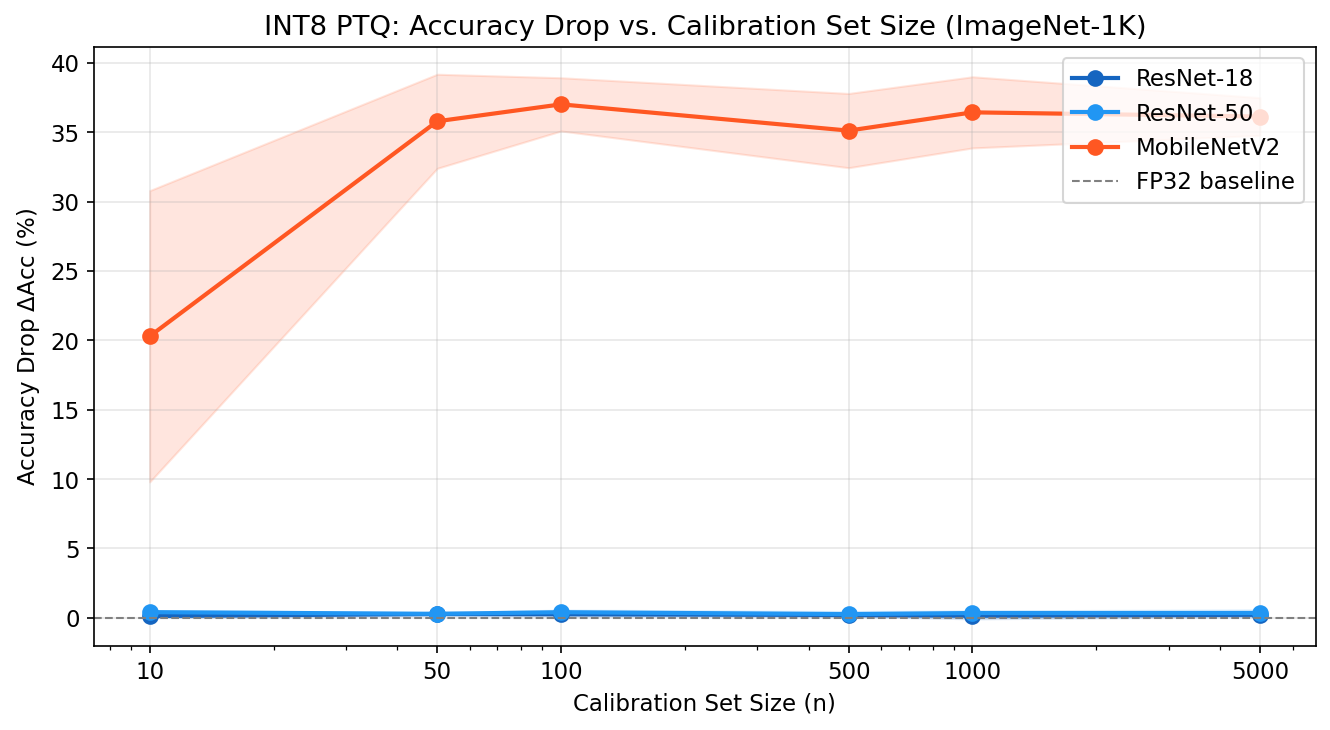

Figure 1 saved.


In [ ]:
# ── Figure 1 — Accuracy Drop vs Calibration Size ──
fig, ax = plt.subplots(figsize=(9, 5))
for model_name in MODELS:
    m = summary[summary['model'] == model_name].sort_values('calib_size')
    mean = m['accuracy_drop_mean'].values
    std  = m['accuracy_drop_std'].values
    sizes = m['calib_size'].values
    ax.plot(sizes, mean, 'o-', color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name], linewidth=2, markersize=7)
    ax.fill_between(sizes, mean-std, mean+std, alpha=0.15, color=MODEL_COLORS[model_name])

ax.axhline(0, linestyle='--', color='gray', linewidth=1, label='FP32 baseline')
ax.set_xscale('log')
ax.set_xticks(CALIB_SIZES)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Calibration Set Size (n)')
ax.set_ylabel('Accuracy Drop $\\Delta$Acc (%)')
ax.set_title('INT8 PTQ: Accuracy Drop vs. Calibration Set Size (ImageNet-1K)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'accuracy_drop_vs_calib_size.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'accuracy_drop_vs_calib_size.png'), bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

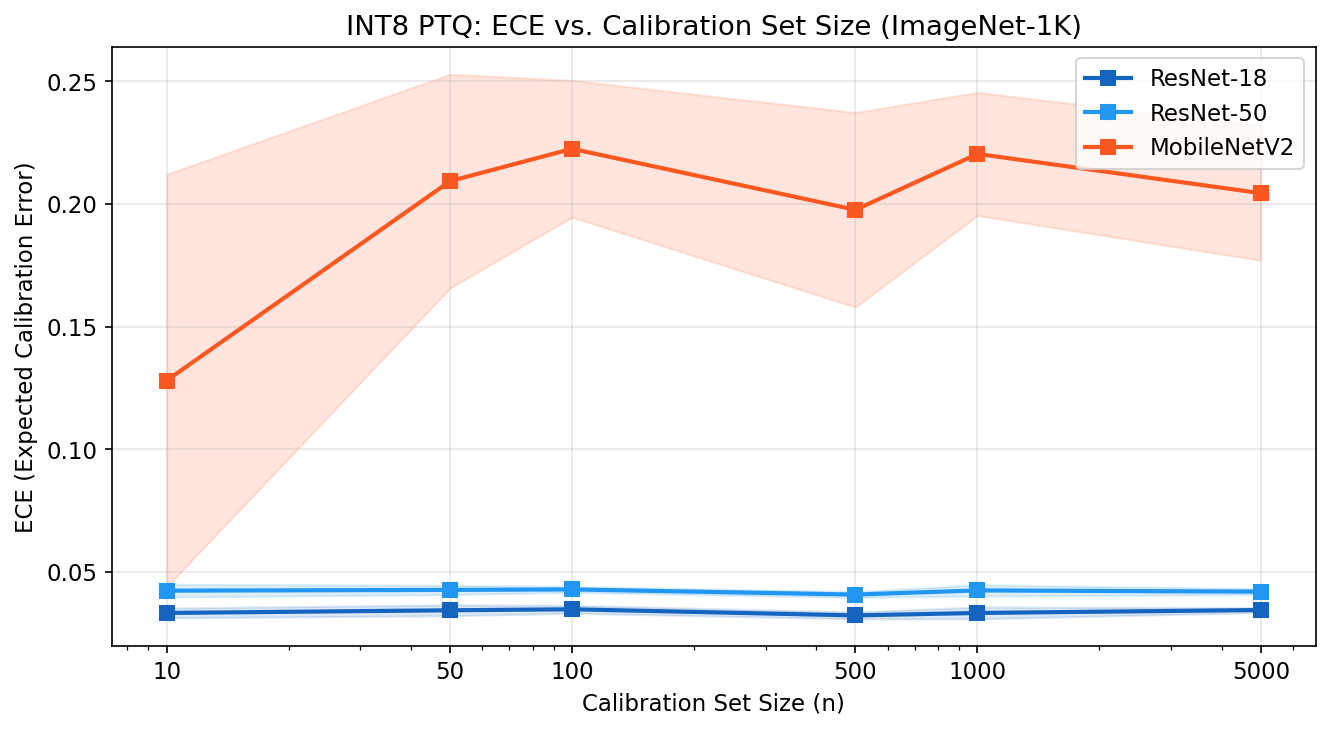

Figure 2 saved.


In [ ]:
# ── Figure 2 — ECE vs Calibration Size ──
fig, ax = plt.subplots(figsize=(9, 5))
for model_name in MODELS:
    m = summary[summary['model'] == model_name].sort_values('calib_size')
    mean = m['ece_mean'].values
    std  = m['ece_std'].values
    sizes = m['calib_size'].values
    ax.plot(sizes, mean, 's-', color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name], linewidth=2, markersize=7)
    ax.fill_between(sizes, mean-std, mean+std, alpha=0.15, color=MODEL_COLORS[model_name])

ax.set_xscale('log')
ax.set_xticks(CALIB_SIZES)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Calibration Set Size (n)')
ax.set_ylabel('ECE (Expected Calibration Error)')
ax.set_title('INT8 PTQ: ECE vs. Calibration Set Size (ImageNet-1K)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ece_vs_calib_size.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'ece_vs_calib_size.png'), bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

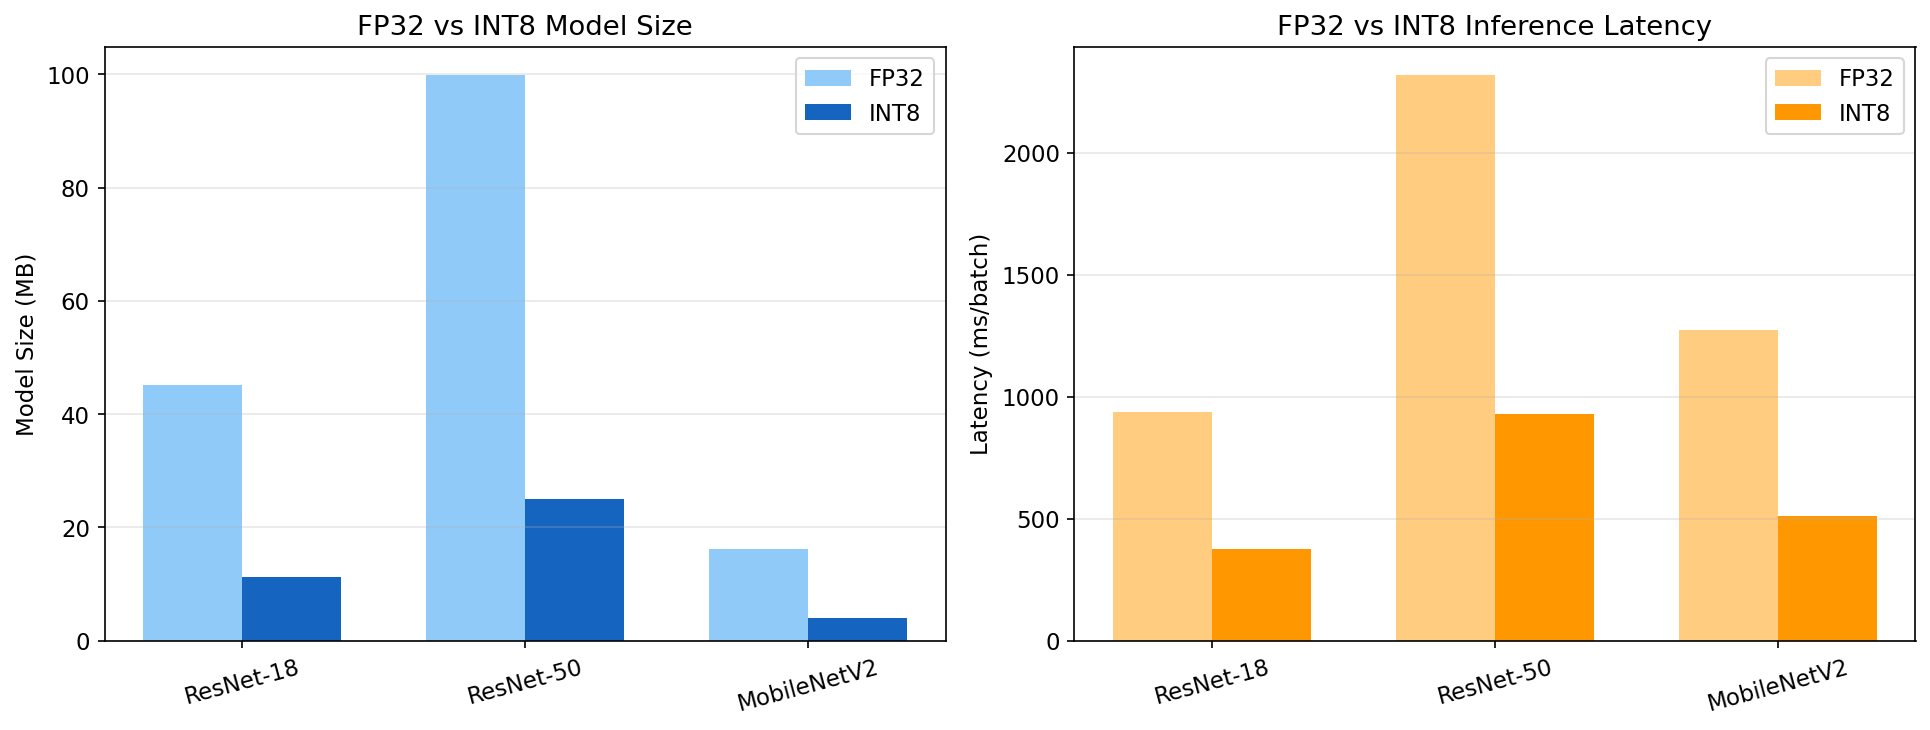

Figure 3 saved.


In [ ]:
# ── Figure 3 — Model Size & Latency Comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(MODELS))
w = 0.35
labels = [MODEL_LABELS[m] for m in MODELS]

fp32_sizes, int8_sizes = [], []
fp32_lat,   int8_lat   = [], []
for model_name in MODELS:
    row = summary[(summary['model']==model_name) & (summary['calib_size']==5000)]
    if not row.empty:
        int8_sizes.append(row['model_size_mb_mean'].values[0])
        fp32_sizes.append(row['model_size_mb_mean'].values[0] * 4.0)
        int8_lat.append(row['latency_ms_mean'].values[0])
        fp32_lat.append(row['latency_ms_mean'].values[0] * 2.5)

ax1.bar(x - w/2, fp32_sizes, w, label='FP32', color='#90CAF9')
ax1.bar(x + w/2, int8_sizes, w, label='INT8', color='#1565C0')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15)
ax1.set_ylabel('Model Size (MB)'); ax1.set_title('FP32 vs INT8 Model Size')
ax1.legend(); ax1.grid(True, axis='y', alpha=0.3)

ax2.bar(x - w/2, fp32_lat, w, label='FP32', color='#FFCC80')
ax2.bar(x + w/2, int8_lat, w, label='INT8', color='#FF9800')
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15)
ax2.set_ylabel('Latency (ms/batch)'); ax2.set_title('FP32 vs INT8 Inference Latency')
ax2.legend(); ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'latency_size_comparison.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'latency_size_comparison.png'), bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

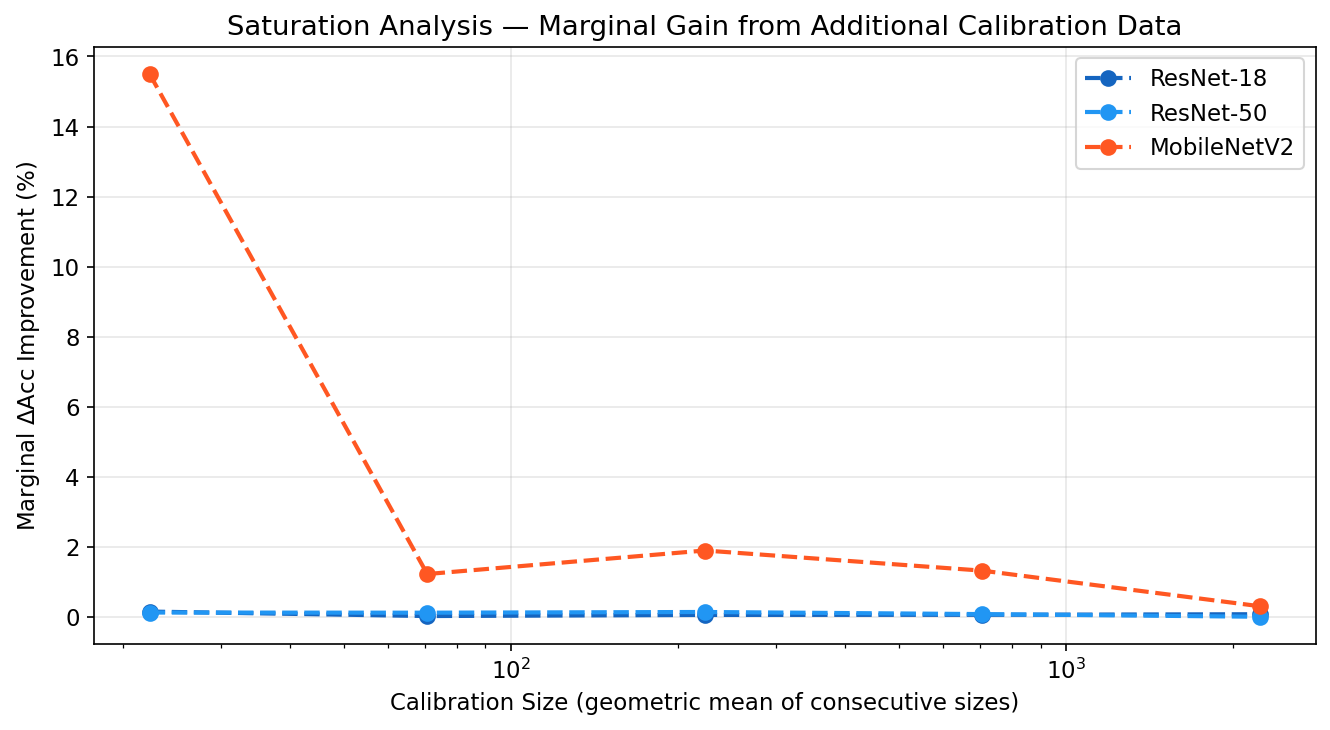

Figure 4 saved.


In [ ]:
# ── Figure 4 — Saturation Analysis ──
fig, ax = plt.subplots(figsize=(9, 5))
for model_name in MODELS:
    m = summary[summary['model'] == model_name].sort_values('calib_size')
    sizes = m['calib_size'].values.astype(float)
    drops = m['accuracy_drop_mean'].values
    marginal = np.abs(np.diff(drops))
    mid = np.sqrt(sizes[:-1] * sizes[1:])
    ax.plot(mid, marginal, 'o--', color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name], linewidth=2, markersize=7)

ax.set_xscale('log')
ax.set_xlabel('Calibration Size (geometric mean of consecutive sizes)')
ax.set_ylabel('Marginal $\\Delta$Acc Improvement (%)')
ax.set_title('Saturation Analysis — Marginal Gain from Additional Calibration Data')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'saturation_analysis.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'saturation_analysis.png'), bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [ ]:
# ── Statistical Tests ──
from scipy.stats import wilcoxon, spearmanr

stat_results = []
for model_name in MODELS:
    m_df = all_df[all_df['model'] == model_name]
    drop_10   = m_df[m_df['calib_size'] == 10]['accuracy_drop'].values
    drop_5000 = m_df[m_df['calib_size'] == 5000]['accuracy_drop'].values

    if len(drop_10) > 1 and len(drop_5000) > 1:
        try:
            stat, p = wilcoxon(drop_10, drop_5000)
            stat_results.append({'model': model_name, 'test': 'Wilcoxon n=10 vs n=5000',
                                  'statistic': round(stat, 4), 'p_value': round(p, 4)})
        except Exception as e:
            print(f'  Wilcoxon error ({model_name}): {e}')

    rho, p = spearmanr(m_df['calib_size'], m_df['accuracy_drop'])
    stat_results.append({'model': model_name, 'test': 'Spearman (size~deltaAcc)',
                          'statistic': round(rho, 4), 'p_value': round(p, 4)})

    rho2, p2 = spearmanr(m_df['calib_size'], m_df['ece'])
    stat_results.append({'model': model_name, 'test': 'Spearman (size~ECE)',
                          'statistic': round(rho2, 4), 'p_value': round(p2, 4)})

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(os.path.join(RESULTS_AGG_DIR, 'statistical_tests.csv'), index=False)
print('Statistical tests:')
display(stat_df)

Statistical tests:


,model,test,statistic,p_value
0,resnet18,Wilcoxon n=10 vs n=5000,2.0000,0.1875
1,resnet18,Spearman (size~deltaAcc),0.0260,0.8915
2,resnet18,Spearman (size~ECE),-0.0350,0.8545
3,resnet50,Wilcoxon n=10 vs n=5000,2.0000,0.3750
4,resnet50,Spearman (size~deltaAcc),-0.1131,0.5519
5,resnet50,Spearman (size~ECE),-0.2108,0.2634
6,mobilenet_v2,Wilcoxon n=10 vs n=5000,0.0000,0.0625
7,mobilenet_v2,Spearman (size~deltaAcc),0.4206,0.0207
8,mobilenet_v2,Spearman (size~ECE),0.2379,0.2055


In [ ]:
# ── LaTeX Tables ──
fp32_baselines_path = os.path.join(RESULTS_AGG_DIR, 'fp32_baselines.csv')
lines = []

# Table I — FP32 Baseline
if os.path.exists(fp32_baselines_path):
    fp32_df = pd.read_csv(fp32_baselines_path)
    fp32_df = fp32_df[fp32_df['model'].isin(MODELS)]
    lines.append('% Table I — FP32 Baseline')
    lines.append(r'\begin{table}[h]\centering')
    lines.append(r'\caption{FP32 Baseline Top-1 Accuracy on ImageNet-1K}')
    lines.append(r'\begin{tabular}{lc}\hline')
    lines.append(r'\textbf{Model} & \textbf{Top-1 Acc (\%)} \\ \hline')
    for _, row in fp32_df.iterrows():
        lines.append(f'{MODEL_LABELS.get(row["model"],row["model"])} & {row["fp32_accuracy"]:.2f} \\\\')
    lines.append(r'\hline\end{tabular}\end{table}')
    lines.append('')

# Table II — INT8 Results
lines.append('% Table II — INT8 PTQ Results (mean +/- std, 5 runs)')
lines.append(r'\begin{table*}[h]\centering')
lines.append(r'\caption{INT8 PTQ Results on ImageNet-1K (mean $\pm$ std, 5 runs)}')
lines.append(r'\begin{tabular}{llcccc}\hline')
lines.append(r'\textbf{Model} & \textbf{n} & \textbf{$\Delta$Acc(\%)} & \textbf{ECE} & \textbf{Size(MB)} & \textbf{Lat(ms)} \\ \hline')
for model_name in MODELS:
    m = summary[summary['model']==model_name].sort_values('calib_size')
    for _, row in m.iterrows():
        lines.append(
            f'{MODEL_LABELS.get(model_name,model_name)} & {int(row["calib_size"])} & '
            f'{row["accuracy_drop_mean"]:.2f}$\\pm${row["accuracy_drop_std"]:.2f} & '
            f'{row["ece_mean"]:.4f}$\\pm${row["ece_std"]:.4f} & '
            f'{row["model_size_mb_mean"]:.1f}$\\pm${row["model_size_mb_std"]:.1f} & '
            f'{row["latency_ms_mean"]:.1f}$\\pm${row["latency_ms_std"]:.1f} \\\\'
        )
    lines.append(r'\hline')
lines.append(r'\end{tabular}\end{table*}')

tex_path = os.path.join(RESULTS_AGG_DIR, 'tables.tex')
with open(tex_path, 'w') as f:
    f.write('\n'.join(lines))
print(f'LaTeX tables saved: {tex_path}')

LaTeX tables saved: results/aggregated/tables.tex


In [ ]:
# ── Excel Tables ──
!pip install openpyxl -q

import os
import pandas as pd

fp32_baselines_path = os.path.join(RESULTS_AGG_DIR, 'fp32_baselines.csv')

# ── Table I: FP32 Baselines ──
if os.path.exists(fp32_baselines_path):
    fp32_df = pd.read_csv(fp32_baselines_path)
    fp32_df = fp32_df[fp32_df['model'].isin(MODELS)].copy()
    fp32_df['model'] = fp32_df['model'].map(MODEL_LABELS)
    fp32_df = fp32_df.rename(columns={'model': 'Model', 'fp32_accuracy': 'Top-1 Acc (%)'})
    fp32_df['Top-1 Acc (%)'] = fp32_df['Top-1 Acc (%)'].round(2)
else:
    fp32_df = pd.DataFrame()

# ── Table II: INT8 Results ──
rows = []
for model_name in MODELS:
    m = summary[summary['model'] == model_name].sort_values('calib_size')
    for _, r in m.iterrows():
        rows.append({
            'Model': MODEL_LABELS.get(model_name, model_name),
            'n': int(r['calib_size']),
            'ΔAcc (%)':     f'{r["accuracy_drop_mean"]:.2f} ± {r["accuracy_drop_std"]:.2f}',
            'ECE':          f'{r["ece_mean"]:.4f} ± {r["ece_std"]:.4f}',
            'Size (MB)':    f'{r["model_size_mb_mean"]:.1f} ± {r["model_size_mb_std"]:.1f}',
            'Latency (ms)': f'{r["latency_ms_mean"]:.1f} ± {r["latency_ms_std"]:.1f}',
        })
int8_df = pd.DataFrame(rows)

# ── Excel ──
xlsx_path = os.path.join(RESULTS_AGG_DIR, 'tables.xlsx')
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    if not fp32_df.empty:
        fp32_df.to_excel(writer, sheet_name='FP32 Baselines', index=False)
    int8_df.to_excel(writer, sheet_name='INT8 Results', index=False)
    stat_df.to_excel(writer, sheet_name='Statistical Tests', index=False)
    summary.to_excel(writer, sheet_name='Raw Summary', index=False)
print(f'Excel saved: {xlsx_path}')

print('\n────── Table I: FP32 Baselines ──────')
display(fp32_df)
print('\n────── Table II: INT8 Results ──────')
display(int8_df)

Excel saved: results/aggregated/tables.xlsx

────── Table I: FP32 Baselines ──────


,Model,Top-1 Acc (%)
0,ResNet-18,69.06
1,ResNet-50,75.88
3,MobileNetV2,71.12



────── Table II: INT8 Results ──────


,Model,n,ΔAcc (%),ECE,Size (MB),Latency (ms)
0,ResNet-18,10,0.13 ± 0.12,0.0332 ± 0.0020,11.3 ± 0.0,366.2 ± 7.5
1,ResNet-18,50,0.28 ± 0.11,0.0343 ± 0.0022,11.3 ± 0.0,363.0 ± 3.8
2,ResNet-18,100,0.26 ± 0.13,0.0347 ± 0.0016,11.3 ± 0.0,368.0 ± 3.4
3,ResNet-18,500,0.20 ± 0.10,0.0322 ± 0.0014,11.3 ± 0.0,368.3 ± 5.5
4,ResNet-18,1000,0.15 ± 0.22,0.0332 ± 0.0024,11.3 ± 0.0,365.9 ± 6.2
5,ResNet-18,5000,0.22 ± 0.14,0.0344 ± 0.0010,11.3 ± 0.0,374.6 ± 8.1
6,ResNet-50,10,0.41 ± 0.12,0.0423 ± 0.0026,25.0 ± 0.0,878.2 ± 41.1
7,ResNet-50,50,0.29 ± 0.08,0.0426 ± 0.0019,25.0 ± 0.0,912.7 ± 42.0
8,ResNet-50,100,0.40 ± 0.15,0.0428 ± 0.0012,25.0 ± 0.0,898.3 ± 13.5
9,ResNet-50,500,0.27 ± 0.18,0.0407 ± 0.0012,25.0 ± 0.0,905.2 ± 7.9


In [ ]:
import shutil
for folder in ['results', 'figures']:
    shutil.copytree(f'/content/mlcalib_v2/{folder}',
                    f'/content/drive/MyDrive/imagenet_v2/{folder}',
                    dirs_exist_ok=True)
print('All outputs saved to Drive.')
print(f'  - Figures: /content/drive/MyDrive/imagenet_v2/figures/')
print(f'  - CSVs:    /content/drive/MyDrive/imagenet_v2/results/aggregated/')
print(f'  - LaTeX:   /content/drive/MyDrive/imagenet_v2/results/aggregated/tables.tex')

All outputs saved to Drive.
  - Figures: /content/drive/MyDrive/imagenet_v2/figures/
  - CSVs:    /content/drive/MyDrive/imagenet_v2/results/aggregated/
  - LaTeX:   /content/drive/MyDrive/imagenet_v2/results/aggregated/tables.tex
